In [23]:
#IMPORTS
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

In [24]:
#LOAD DATA
file_path = r"C:\Users\harini.tadinada\OneDrive - Altera\Product Qualification - AI & ML\Documents\Project\Project_5\Project 5_1.csv"

df = pd.read_csv(file_path)

print("Loaded shape:", df.shape)

Loaded shape: (3059, 34640)


In [25]:
#INITIAL CLEANING
# Target
y = df['Pass_Fail'].map({'Fail': 1, 'Pass': 0})

# Features
X = df.drop(columns=['Pass_Fail'])

# Drop ID columns
drop_cols = ['LOT7','TP','sort_lot','visual_id','lwxy']
X = X.drop(columns=[c for c in drop_cols if c in X.columns])

# Convert numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Replace junk values
sentinels = [-999, -777, -555, -888, -666]
X = X.replace(sentinels, np.nan)
X = X.mask(X < -100, np.nan)

print("Initial cleaned shape:", X.shape)


Initial cleaned shape: (3059, 34638)


In [26]:
#REMOVE EMPTY COLUMNS
nan_ratio = X.isna().mean()

empty_cols = nan_ratio[nan_ratio == 1.0].index
print("Dropping empty columns:", len(empty_cols))

X = X.drop(columns=empty_cols)

print("After removing empty columns:", X.shape)


Dropping empty columns: 310
After removing empty columns: (3059, 34328)


In [27]:
#FILL REMAINING NaNs
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Remaining NaNs:", X.isna().sum().sum())


Remaining NaNs: 0



Target distribution:
Pass_Fail
0    2962
1      97
Name: count, dtype: int64


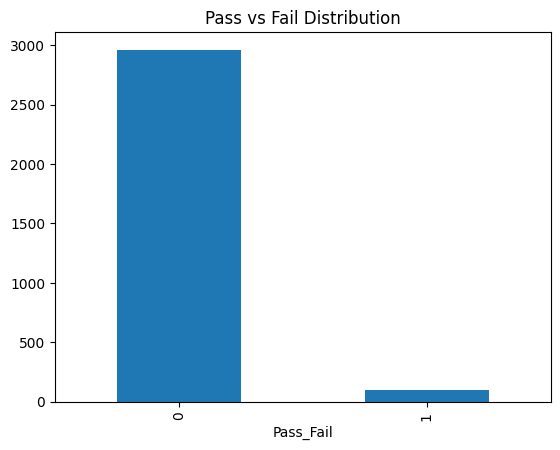


Top separating features:
DFF_TULHSH0@12                                                              1.012829e+84
DFF_ULHSH0@13                                                               1.012829e+84
DFF_TICARPN0@12                                                             6.759689e+15
DFF_ICARPN0@13                                                              6.759689e+15
DFF_ICARPS0@13                                                              3.748143e+14
DFF_TICARPS0@12                                                             3.748143e+14
VMU_VB_TPI_BASE::CTRL_BKGND_X_K_TESTPLANENDFLOW_X_X_X_X_STOPTIMENOBIN@13    2.369104e+08
PCS_VMU_VB@13                                                               2.369104e+08
MEM0_BEGIN_VMU_PB_TPI_BASE::CTRL_X_X_E_BEGIN_X_X_X_X_MEMUSE@13              2.360810e+08
PCS_VMU_PB@12                                                               6.873813e+07
PCS_VMU_VB@12                                                               6.312510

In [28]:
#EDA 
print("\nTarget distribution:")
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title("Pass vs Fail Distribution")
plt.show()

# Feature separation
fail_mean = X[y == 1].mean()
pass_mean = X[y == 0].mean()

diff = (fail_mean - pass_mean).abs().sort_values(ascending=False)

print("\nTop separating features:")
print(diff.head(20))

In [29]:
#FEATURE SELECTION
top_features = diff.head(300).index

X = X[top_features]

print("After feature selection:", X.shape)

After feature selection: (3059, 300)


In [30]:
#FEATURE ENGINEERING
X = X.copy()

if 'DD1@9910' in X.columns and 'RADIUS@9910' in X.columns:
    X['DD1_minus_RADIUS'] = X['DD1@9910'] - X['RADIUS@9910']
    X['DD1_ratio'] = X['DD1@9910'] / (X['RADIUS@9910'] + 1)

# Clean again
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Final shape:", X.shape)
print("Final NaNs:", X.isna().sum().sum())


Final shape: (3059, 300)
Final NaNs: 0


In [31]:
# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Clip extreme values (VERY IMPORTANT)
X = X.clip(lower=-1e6, upper=1e6)

In [32]:
X = X.fillna(X.median())

print("NaNs after final cleanup:", X.isna().sum().sum())

NaNs after final cleanup: 0


In [33]:
#TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [34]:
#NORMALIZATION (ONLY FOR SOME MODELS)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [35]:
#EVALUATION FUNCTION
model_outputs = {}

def evaluate_model(name, model, use_scaled=False):
    
    print(f"\n===== {name} =====")
    
    if use_scaled:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
    
    model.fit(X_tr, y_train)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.predict(X_te)
    
    model_outputs[name] = y_prob
    
    threshold = 0.02
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(pd.DataFrame(
        cm,
        index=["Actual Pass", "Actual Fail"],
        columns=["Pred Pass", "Pred Fail"]
    ))
    
    escape = fn / (tp + fn)
    overkill = fp / (fp + tn)
    auc_score = roc_auc_score(y_test, y_prob)
    
    print(f"\nFN: {fn}, FP: {fp}")
    print(f"Escape %: {escape*100:.2f}%")
    print(f"Overkill %: {overkill*100:.2f}%")
    print(f"AUC: {auc_score:.4f}")
    
    # ✅ Save results
    results.append({
        "Model": name,
        "FN": fn,
        "FP": fp,
        "Escape (%)": escape*100,
        "Overkill (%)": overkill*100,
        "AUC": auc_score,
        "ModelObject": model,
        "Pred": y_pred
    })



In [36]:
results = []

In [37]:
# Reset results tracking
results = []
model_outputs = {}

In [38]:
#RUN MODELS
# ===== MODELS WITH CLASS IMBALANCE HANDLING =====

# ✅ Logistic Regression (balanced)
evaluate_model(
    "Logistic Regression (Balanced)",
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    use_scaled=True
)

# ✅ SVM (balanced)
evaluate_model(
    "SVM (Balanced)",
    SVC(probability=True, class_weight='balanced'),
    use_scaled=True
)

# ✅ Decision Tree (balanced)
evaluate_model(
    "Decision Tree (Balanced)",
    DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    use_scaled=False
)

# ✅ Gradient Boosting (unchanged)
evaluate_model(
    "Gradient Boosting",
    GradientBoostingClassifier(),
    use_scaled=False
)

# ✅ XGBoost (already handling imbalance ✅)
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    reg_alpha=1,
    reg_lambda=10,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)

evaluate_model("XGBoost", xgb_model, use_scaled=False)


===== Logistic Regression (Balanced) =====
             Pred Pass  Pred Fail
Actual Pass         15        874
Actual Fail          0         29

FN: 0, FP: 874
Escape %: 0.00%
Overkill %: 98.31%
AUC: 0.6819

===== SVM (Balanced) =====
             Pred Pass  Pred Fail
Actual Pass        628        261
Actual Fail          9         20

FN: 9, FP: 261
Escape %: 31.03%
Overkill %: 29.36%
AUC: 0.7488

===== Decision Tree (Balanced) =====
             Pred Pass  Pred Fail
Actual Pass        584        305
Actual Fail          7         22

FN: 7, FP: 305
Escape %: 24.14%
Overkill %: 34.31%
AUC: 0.7812

===== Gradient Boosting =====
             Pred Pass  Pred Fail
Actual Pass        832         57
Actual Fail         15         14

FN: 15, FP: 57
Escape %: 51.72%
Overkill %: 6.41%
AUC: 0.8069

===== XGBoost =====
             Pred Pass  Pred Fail
Actual Pass         37        852
Actual Fail          0         29

FN: 0, FP: 852
Escape %: 0.00%
Overkill %: 95.84%
AUC: 0.8094


In [39]:
#SELECT BEST MODEL
results_df = pd.DataFrame(results)

print("\n===== MODEL COMPARISON =====")
print(results_df[['Model','FN','FP','Escape (%)','Overkill (%)','AUC']])


===== MODEL COMPARISON =====
                            Model  FN   FP  Escape (%)  Overkill (%)       AUC
0  Logistic Regression (Balanced)   0  874    0.000000     98.312711  0.681898
1                  SVM (Balanced)   9  261   31.034483     29.358830  0.748807
2        Decision Tree (Balanced)   7  305   24.137931     34.308211  0.781195
3               Gradient Boosting  15   57   51.724138      6.411699  0.806873
4                         XGBoost   0  852    0.000000     95.838020  0.809395


In [40]:
#SELECT BEST MODEL
best_model_row = results_df.sort_values(
    by=["FN", "FP"]
).iloc[0]

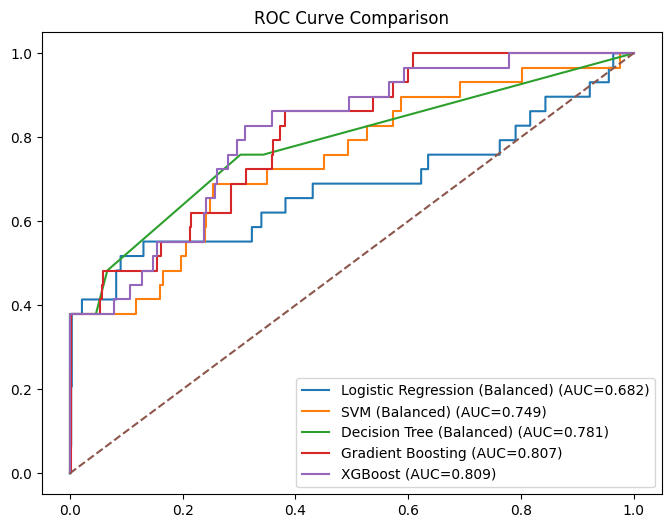

In [41]:
#ROC CURVES
plt.figure(figsize=(8,6))

for name, y_prob in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

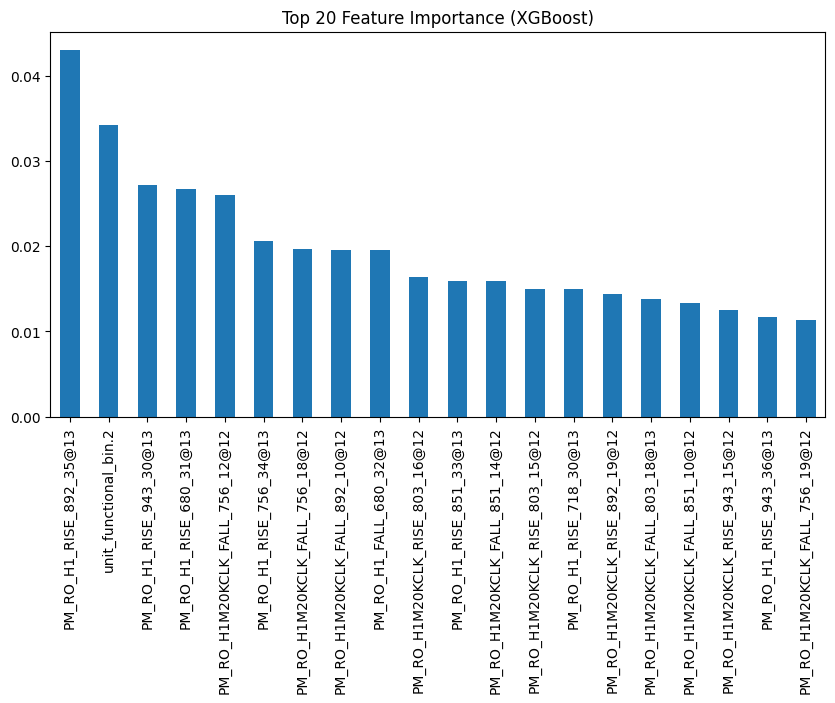

In [42]:
#FEATURE IMPORTANCE
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(20).plot(kind='bar', figsize=(10,5))

plt.title("Top 20 Feature Importance (XGBoost)")
plt.show()

In [43]:
#FINAL CONFUSION MATRIX
results_df = pd.DataFrame(results)

print("\n===== MODEL COMPARISON =====")
print(results_df[['Model','FN','FP','Escape (%)','Overkill (%)','AUC']])

#DEFINE BEST MODEL
best_model_row = results_df.sort_values(
    by=["FN", "FP"]
).iloc[0]

print("\n✅ BEST MODEL SELECTED:")
print(best_model_row[['Model','FN','FP','Escape (%)','Overkill (%)','AUC']])

#FINAL CONFUSION MATRIX
best_pred = best_model_row["Pred"]

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

print("\n===== FINAL CONFUSION MATRIX =====")

print(pd.DataFrame(
    cm,
    index=["Actual Pass", "Actual Fail"],
    columns=["Pred Pass", "Pred Fail"]
))

print("\n----- FINAL METRICS -----")
print(f"Best Model: {best_model_row['Model']}")
print(f"FN: {fn}")
print(f"FP: {fp}")
print(f"Escape %: {fn/(tp+fn)*100:.2f}%")
print(f"Overkill %: {fp/(fp+tn)*100:.2f}%")
print(f"AUC: {best_model_row['AUC']:.4f}")


===== MODEL COMPARISON =====
                            Model  FN   FP  Escape (%)  Overkill (%)       AUC
0  Logistic Regression (Balanced)   0  874    0.000000     98.312711  0.681898
1                  SVM (Balanced)   9  261   31.034483     29.358830  0.748807
2        Decision Tree (Balanced)   7  305   24.137931     34.308211  0.781195
3               Gradient Boosting  15   57   51.724138      6.411699  0.806873
4                         XGBoost   0  852    0.000000     95.838020  0.809395

✅ BEST MODEL SELECTED:
Model            XGBoost
FN                     0
FP                   852
Escape (%)           0.0
Overkill (%)    95.83802
AUC             0.809395
Name: 4, dtype: object

===== FINAL CONFUSION MATRIX =====
             Pred Pass  Pred Fail
Actual Pass         37        852
Actual Fail          0         29

----- FINAL METRICS -----
Best Model: XGBoost
FN: 0
FP: 852
Escape %: 0.00%
Overkill %: 95.84%
AUC: 0.8094


In [44]:
#SORT BY AUC (Optional)
print("\n===== SORTED BY AUC =====")
print(results_df.sort_values(by="AUC", ascending=False)[
    ['Model','FN','FP','Escape (%)','Overkill (%)','AUC']
])


===== SORTED BY AUC =====
                            Model  FN   FP  Escape (%)  Overkill (%)       AUC
4                         XGBoost   0  852    0.000000     95.838020  0.809395
3               Gradient Boosting  15   57   51.724138      6.411699  0.806873
2        Decision Tree (Balanced)   7  305   24.137931     34.308211  0.781195
1                  SVM (Balanced)   9  261   31.034483     29.358830  0.748807
0  Logistic Regression (Balanced)   0  874    0.000000     98.312711  0.681898
